# Assignment 1A — Part A
Run the PDF, cleaning, split, token packing, CPT, perplexity, and forgetting stages.

In [2]:
#GPU Enabled Testing
!nvidia-smi

Tue Sep  1 03:41:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1. Clone the GitHub repository

In [3]:
from pathlib import Path
import subprocess
import os

REPO_URL = "https://github.com/tusharchouhan/banking-compliance-llm-assignment-1a.git"
PROJECT = Path("/content/banking-compliance-llm-assignment-1a")

if not (PROJECT / "src").exists():
    subprocess.run(["git", "clone", REPO_URL, str(PROJECT)], check=True)

os.chdir(PROJECT)
print("Project:", Path.cwd())
print("src exists:", (PROJECT / "src").exists())

Project: /content/banking-compliance-llm-assignment-1a
src exists: True


In [4]:
!ls

'Assignment Documentation'      models	    reports	       run_pipeline.py
 assignment_part_master.ipynb   notebooks   requirements.txt   src
 data			        README.md   results


### Install dependencies

In [5]:
# Install dependencies
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 27.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.1/385.1 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 992.6/992.6 kB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 20.0 MB/s eta 0:00:00


### Verify GPU:

In [6]:
#Verify GPU:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: Tesla T4


### 3. Mount Google Drive and copy PDFs

In [7]:
#3. Mount Google Drive and copy PDFs
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
from pathlib import Path
import shutil

DRIVE_RAW = Path("/content/drive/MyDrive/LLM_ASSIGNMENT_DATA/raw_pdfs")
LOCAL_RAW = PROJECT / "data" / "raw_pdfs"

if not DRIVE_RAW.exists():
    raise FileNotFoundError(f"Missing Drive folder: {DRIVE_RAW}")

shutil.copytree(DRIVE_RAW, LOCAL_RAW, dirs_exist_ok=True)

pdfs = [
    p for p in LOCAL_RAW.rglob("*")
    if p.is_file() and p.suffix.lower() == ".pdf"
]

total_mb = sum(p.stat().st_size for p in pdfs) / (1024 * 1024)

print("PDF count:", len(pdfs))
print("Total size:", round(total_mb, 2), "MB")
print("First PDF:", pdfs[0] if pdfs else "None")

PDF count: 127
Total size: 159.65 MB
First PDF: /content/banking-compliance-llm-assignment-1a/data/raw_pdfs/SEBI/1783933012694.pdf


In [9]:
from pathlib import Path
import sys
ROOT=Path.cwd() / 'LLM_ASSIGNMENT' if (Path.cwd()/'LLM_ASSIGNMENT').exists() else Path.cwd()
sys.path.insert(0,str(ROOT))

### Extract Clean and Split the corpus

In [10]:
# Extract Clean and Split the corpus
!python -m src.data.pdf_extractor

2026-09-01 03:43:42,613 | INFO | pdf_extractor | Extracted 201712-standards-basel-iii-finalising-post-crisis-reforms.pdf: 162 pages, 535392 characters
2026-09-01 03:43:42,634 | INFO | pdf_extractor | Extracted Addendum - Guidelines for Corporate Governance for Insurers in India.pdf: 1 pages, 1971 characters
2026-09-01 03:43:42,962 | INFO | pdf_extractor | Extracted GUIDELINES FOR INTENSIVE EXAMINATION OF PUBLIC PROCUREMENT CONTRACTS BY.pdf: 10 pages, 17112 characters
2026-09-01 03:43:45,272 | INFO | pdf_extractor | Extracted Guidelines for Corporate Governance for insurers in India.pdf: 67 pages, 134077 characters
2026-09-01 03:43:45,607 | INFO | pdf_extractor | Extracted Guidelines on Appointment of Insurance Agents 2015 –Instructions to Insurer.pdf: 3 pages, 5536 characters
2026-09-01 03:43:47,172 | INFO | pdf_extractor | Extracted Guidelines on Cross Border Re-insurers.pdf: 15 pages, 14814 characters
2026-09-01 03:43:47,185 | INFO | pdf_extractor | Extracted Guidelines on Establishm

In [11]:
import pandas as pd

pd.read_csv("reports/tables/extraction_report.csv").head()

,source_pdf,output_txt,pages,characters,status
0,Basel/201712-standards-basel-iii-finalising-po...,Basel/201712-standards-basel-iii-finalising-po...,162,535392,ok
1,IRDA/Addendum - Guidelines for Corporate Gover...,IRDA/Addendum - Guidelines for Corporate Gover...,1,1971,ok
2,IRDA/GUIDELINES FOR INTENSIVE EXAMINATION OF P...,IRDA/GUIDELINES FOR INTENSIVE EXAMINATION OF P...,10,17112,ok
3,IRDA/Guidelines for Corporate Governance for i...,IRDA/Guidelines for Corporate Governance for i...,67,134077,ok
4,IRDA/Guidelines on Appointment of Insurance Ag...,IRDA/Guidelines on Appointment of Insurance Ag...,3,5536,ok


### Run Clean

In [12]:
# Run Clean
!python -m src.data.clean_corpus

2026-09-01 03:47:28,211 | INFO | clean_corpus | Cleaning complete: 127 -> 118 documents


In [13]:
pd.read_csv("reports/tables/cleaning_report.csv")

,step,documents,removed,impact
0,input,127,0,baseline
1,input,127,0,NaN
2,length_filter,125,2,NaN
3,repetition_filter,125,0,NaN
4,deduplication,123,2,NaN
5,english_filter,118,5,greatest


### Run the 90/10 split:

In [14]:
# Run the 90/10 split:
!python -m src.data.train_eval_split

2026-09-01 03:47:28,431 | INFO | train_eval_split | Split 118 documents into 106 train and 12 eval files


### Verify both folders:

In [15]:
#Verify both folders:
!find data/train_corpus -type f -iname "*.txt" | wc -l
!find data/eval_corpus -type f -iname "*.txt" | wc -l

106
12


### 5. Tokenize and pack

In [16]:
#5. Tokenize and pack
!python -m src.data.tokenize_and_pack --seq-len 1024


2026-09-01 03:47:41,040 | INFO | numexpr.utils | NumExpr defaulting to 2 threads.
2026-09-01 03:47:41,901 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-09-01 03:47:41,986 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/HuggingFaceTB/SmolLM2-360M/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-09-01 03:47:41,986 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-01 03:47:41,998 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HuggingFaceTB/SmolLM2-360M/f8027fd0eaeea54caa13c31d31b9fdc459c38b49/config.json "HTTP/1.1 200 OK"
2026-09-01 03:47:42,012 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/HuggingFaceTB/SmolLM2-360M/f8027fd0eaeea54caa13c31d31b9fdc459c38b49/config.json "HTTP/1.1 200 OK"
config.json: 1

### Verify

In [17]:
#Verify
!ls -lh data/train_packed.parquet

-rw-r--r-- 1 root root 4.2M Sep  1 03:47 data/train_packed.parquet


In [18]:
pd.read_csv("reports/tables/token_statistics.csv")

,model_id,sequence_length,documents,total_tokens_with_bos_eos,average_document_tokens,packed_sequences,discarded_tail_tokens,seed
0,HuggingFaceTB/SmolLM2-360M,1024,106,2868001,27054.61,2800,801,42


### 6. Model inspection and baseline

In [19]:
#6. Model inspection and baseline
!python -m src.evaluation.model_inspection
!python -m src.evaluation.baseline_inference

2026-09-01 03:48:07,989 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/HuggingFaceTB/SmolLM2-360M/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-09-01 03:48:07,989 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-01 03:48:08,000 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HuggingFaceTB/SmolLM2-360M/f8027fd0eaeea54caa13c31d31b9fdc459c38b49/config.json "HTTP/1.1 200 OK"
2026-09-01 03:48:09,928 | INFO | numexpr.utils | NumExpr defaulting to 2 threads.
2026-09-01 03:48:10,260 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/HuggingFaceTB/SmolLM2-360M/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-09-01 03:48:10,271 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HuggingFaceTB/SmolLM2-360M/f8027fd0eaeea54caa13c31d31b9fdc459c

### Report

In [20]:
# Report
pd.read_csv("reports/tables/model_architecture.csv")

,model_id,total_parameters,trainable_parameters,decoder_layers,attention_heads,hidden_size,vocabulary_size,head_dimension,lm_head_output_dimension,lm_head_matches_vocab
0,HuggingFaceTB/SmolLM2-360M,361821120,361821120,32,15,960,49152,64,49152,True


In [21]:
pd.read_csv("results/baseline_outputs/baseline_outputs.csv")

,prompt,response
0,What is KYC?,KYC stands for Know Your Customer. It is a pro...
1,What is LTV Ratio?,LTV ratio is a ratio that measures the percent...
2,What is Basel III?,Basel III is a new set of rules that banks mus...


### 7. Run CPT

In [22]:
#7. Run CPT
!python -m src.training.cpt_train --max-steps 500


2026-09-01 03:48:53,557 | INFO | datasets | TensorFlow version 2.20.0 available.
2026-09-01 03:48:53,558 | INFO | datasets | JAX version 0.11.1 available.
2026-09-01 03:48:54,590 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/HuggingFaceTB/SmolLM2-360M/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-09-01 03:48:54,591 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-01 03:48:54,602 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HuggingFaceTB/SmolLM2-360M/f8027fd0eaeea54caa13c31d31b9fdc459c38b49/config.json "HTTP/1.1 200 OK"
2026-09-01 03:48:54,698 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/HuggingFaceTB/SmolLM2-360M/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-09-01 03:48:54,713 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/

### Generating Loss Report:

In [23]:
#Generating Loss Report:
!python -m src.evaluation.loss_analysis

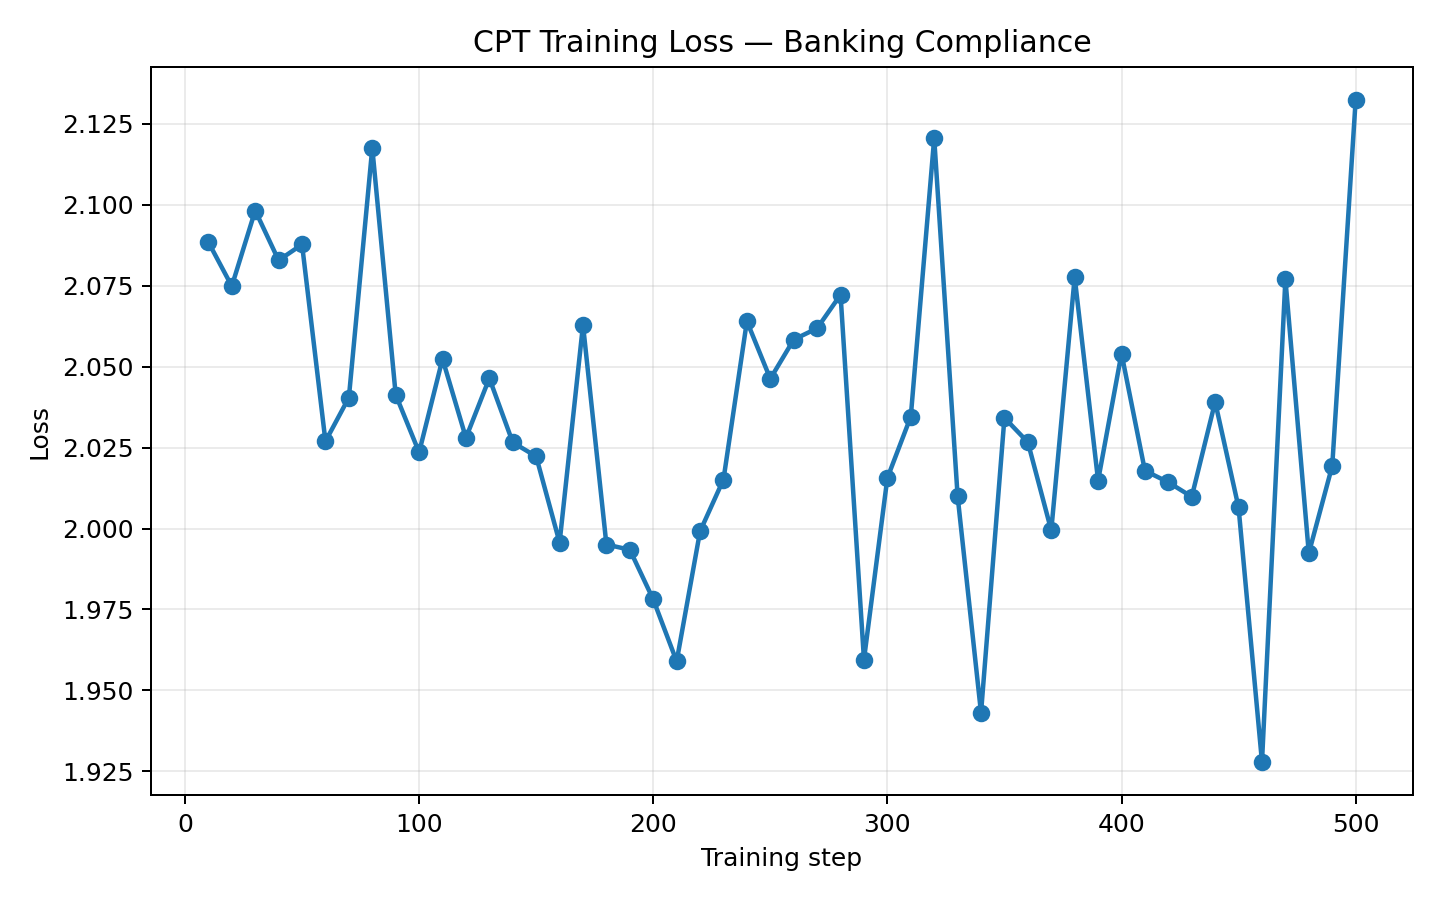

In [24]:
from IPython.display import Image, display

display(Image(filename="reports/figures/loss_curve.png"))

### 8. Run perplexity and forgetting evaluation

In [25]:
#8. Run perplexity and forgetting evaluation
from pathlib import Path

eval_files = [
    p for p in Path("data/eval_corpus").rglob("*")
    if p.is_file() and p.suffix.lower() == ".txt"
]

print("Evaluation files:", len(eval_files))

Evaluation files: 12


In [26]:
!python -m src.evaluation.perplexity
!python -m src.evaluation.forgetting_check
!python -m src.evaluation.build_report

2026-09-01 05:45:32,460 | INFO | numexpr.utils | NumExpr defaulting to 2 threads.
2026-09-01 05:45:32,949 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/HuggingFaceTB/SmolLM2-360M/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-09-01 05:45:32,950 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-01 05:45:32,961 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HuggingFaceTB/SmolLM2-360M/f8027fd0eaeea54caa13c31d31b9fdc459c38b49/config.json "HTTP/1.1 200 OK"
2026-09-01 05:45:33,250 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/HuggingFaceTB/SmolLM2-360M/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-09-01 05:45:33,262 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HuggingFaceTB/SmolLM2-360M/f8027fd0eaeea54caa13c31d3

### Display Perplexity

In [27]:
# Display Perplexity
pd.read_csv("results/perplexity/ppl_results.csv")

,base_model,cpt_model,evaluation_documents,base_ppl,cpt_ppl,percentage_improvement
0,HuggingFaceTB/SmolLM2-360M,/content/banking-compliance-llm-assignment-1a/...,12,8.352,7.7244,7.51


### Display forgetting results:

In [28]:
# Display forgetting results:
from IPython.display import Markdown, display

display(Markdown(
    Path("results/forgetting_check/forgetting_comparison.md").read_text()
))

| Prompt | Base model | CPT model | Verdict |
|---|---|---|---|
| The capital of France is | Paris. It is the largest city in France and the second largest in Europe. It is also the most populous city in Europe. It is the capital | the city of Paris. It is the largest city in France and the capital of the European Union. It is also the capital of the European country of | Retained |
| Water boils at | 100 degrees Celsius.  The boiling point of water is 100 degrees Celsius.  The boiling point of water is | 100 degrees Celsius.  The boiling point of water is 100 degrees Celsius.  The boiling point of water is | Retained |
| The speed of light is approximately | 186,000 miles per second.  The speed of light is the fastest speed in the universe.  The speed | 300,000 kilometers per second.  The speed of light is the fastest speed in the universe.  The speed | Retained |


### Save Part A outputs to Google Drive

In [29]:
#Save Part A outputs to Google Drive
from pathlib import Path
import shutil

SAVE_DIR = Path("/content/drive/MyDrive/LLM_ASSIGNMENT_PART_A_RESULTS")

items = [
    "data/cleaned_txt",
    "data/train_corpus",
    "data/eval_corpus",
    "data/train_packed.parquet",
    "reports",
    "results",
    "models/cpt_model",
]

for item in items:
    source = PROJECT / item
    destination = SAVE_DIR / item

    if source.is_dir():
        shutil.copytree(source, destination, dirs_exist_ok=True)
    elif source.is_file():
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source, destination)

print("Part A saved to:", SAVE_DIR)

Part A saved to: /content/drive/MyDrive/LLM_ASSIGNMENT_PART_A_RESULTS
